# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from numpy.typing import NDArray
from dprs import sim

In [2]:
params = dict(
    n_x = 3_000,
    n_y = 5_000,
    # n_z = 1,
    p = 0.5,
    n_iterations = 50,
    serial_skip = 10,
    n_threads = 16,
)

Execute the Rust-coded sim:

In [3]:
raw_lattice: list = sim.dp(**params)


Dimension:   D2
Grid shape:  (3000, 5000, 1)
Probability: 0.5
Iterations:  50
Serial skip: 10
Threads:     16

Serial:   2.630s
Parallel: 0.232s
Speedup => 11.32x



The final model lattice is returned as a 1d list; next we convert it into the correctly shaped numpy array (2d grid):

In [4]:
lattice: NDArray = np.array(raw_lattice, dtype=np.bool,) \
                    .reshape(params["n_x"], params["n_y"],)

Plot the lower-left portion of the lattice:

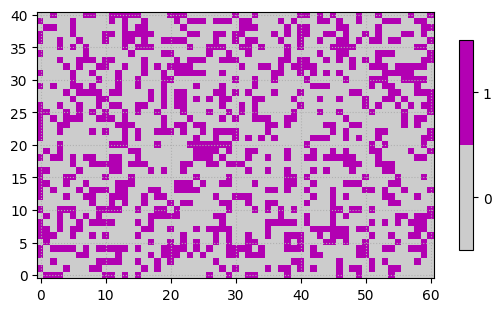

In [5]:
color_map = ListedColormap(((0.8, 0.8, 0.8,), (0.7, 0, 0.7),))
plt.imshow(((lattice[0:61,0:41].T)), cmap=color_map, origin="lower",)
color_bar = plt.colorbar(
    ticks=(0.25, 0.75,), 
    shrink=0.5*(params["n_y"]/params["n_x"])**0.25, 
    aspect=15,
)
color_bar.set_ticklabels((0, 1,),)
plt.grid(ls=":")
plt.show()